# WASMOS results analysis

Loads decrypted results from `demo_results/acr`, `demo_results/dcr`, and `demo_results/ccr` (synthetic data — see `scripts/generate_synthetic_results.py`) and visualizes them.

To analyze real results instead: put the downloaded `wasmos-results-*.json` files in a directory and point `ACR_DIR` / `DCR_DIR` / `CCR_DIR` below at it. Decryption uses the `testId`/`participantId` fields already inside each file, so no extra setup is needed.

In [1]:
import sys
sys.path.insert(0, "../scripts")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wasmos_analysis import load_results_dir

ACR_DIR = "demo_results/acr"
DCR_DIR = "demo_results/dcr"
CCR_DIR = "demo_results/ccr"

acr = load_results_dir(ACR_DIR)
dcr = load_results_dir(DCR_DIR)
ccr = load_results_dir(CCR_DIR)
print(f"ACR: {len(acr)} ratings from {acr['participantId'].nunique()} listeners")
print(f"DCR: {len(dcr)} ratings from {dcr['participantId'].nunique()} listeners")
print(f"CCR: {len(ccr)} ratings from {ccr['participantId'].nunique()} listeners")
acr.head()

ACR: 250 ratings from 50 listeners
DCR: 250 ratings from 50 listeners
CCR: 250 ratings from 50 listeners


,testId,participantId,itemId,rating,timestamp,background_age,background_languageSkills
0,demo-acr-001,P001,pink_20db,3,2026-09-17T07:51:50.522205+00:00,38,Fluent
1,demo-acr-001,P001,white_5db,2,2026-09-17T07:51:55.522205+00:00,38,Fluent
2,demo-acr-001,P001,clean,4,2026-09-17T07:52:00.522205+00:00,38,Fluent
3,demo-acr-001,P001,white_20db,4,2026-09-17T07:52:05.522205+00:00,38,Fluent
4,demo-acr-001,P001,pink_5db,1,2026-09-17T07:52:10.522205+00:00,38,Fluent


## Chart style

Colors follow the project's data-viz palette: a single accent hue for plain magnitude bars (nothing to distinguish by identity beyond the x-axis label itself), and the first two categorical slots — in their documented fixed order — only where two real series (white vs. pink noise) appear together.

In [2]:
# Light-surface chart chrome + palette slots 1 (blue) and 2 (orange), taken
# from the project's validated default palette in their documented fixed order.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES_1 = "#2a78d6"  # blue — default single-hue accent
SERIES_2 = "#eb6834"  # orange — second series, used only when 2 series appear
DIVERGING_POS = "#2a78d6"  # blue — diverging pair, positive pole (B better)
DIVERGING_NEG = "#e34948"  # red — diverging pair, negative pole (B worse)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def style_axes(ax):
    ax.spines["left"].set_color(BASELINE)
    ax.spines["bottom"].set_color(BASELINE)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

## ACR — mean quality rating per condition

Bars sorted by mean rating (highest quality first), with 95% confidence intervals.

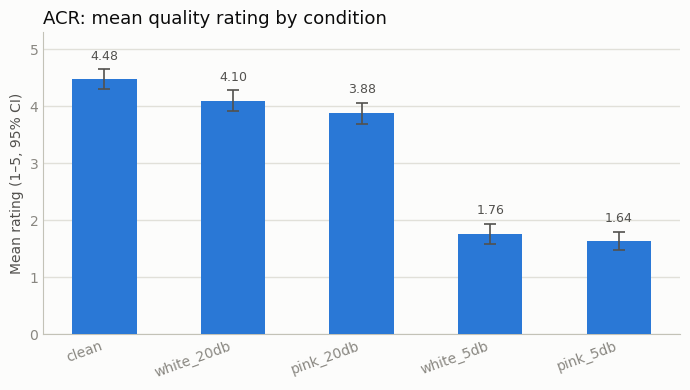

In [3]:
def mean_ci(df, group_col="itemId", value_col="rating"):
    g = df.groupby(group_col)[value_col]
    stats = g.agg(mean="mean", std="std", n="count")
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["n"])
    return stats.sort_values("mean", ascending=False)


def plot_magnitude_bar(stats, title, ylabel, ylim=(0, 5.3)):
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(stats))
    bars = ax.bar(x, stats["mean"], width=0.5, color=SERIES_1, zorder=3,
                  yerr=stats["ci95"], capsize=4,
                  error_kw={"ecolor": INK_SECONDARY, "elinewidth": 1.2, "capthick": 1.2})
    for xi, row in zip(x, stats.itertuples()):
        ax.text(xi, row.mean + row.ci95 + 0.12, f"{row.mean:.2f}",
                ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.set_title(title, color=INK_PRIMARY, fontsize=13, loc="left")
    style_axes(ax)
    fig.tight_layout()
    return fig, ax


acr_stats = mean_ci(acr)
plot_magnitude_bar(acr_stats, "ACR: mean quality rating by condition", "Mean rating (1–5, 95% CI)")
plt.show()

## DCR — mean degradation rating per condition

Higher = less perceptible degradation (5 = imperceptible, 1 = very annoying).

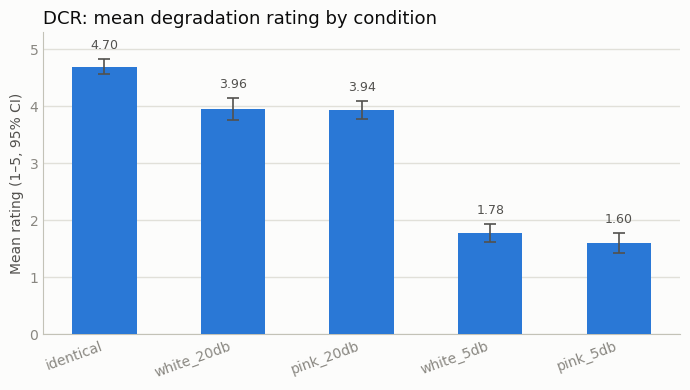

In [4]:
dcr_stats = mean_ci(dcr)
plot_magnitude_bar(dcr_stats, "DCR: mean degradation rating by condition", "Mean rating (1–5, 95% CI)")
plt.show()

## CCR — mean comparison rating per pair

Positive = B rated better than A, negative = B rated worse, 0 = about the same. This is genuinely diverging data (a sign around a meaningful zero), so bars use the project's diverging blue/red pair instead of a single accent hue.

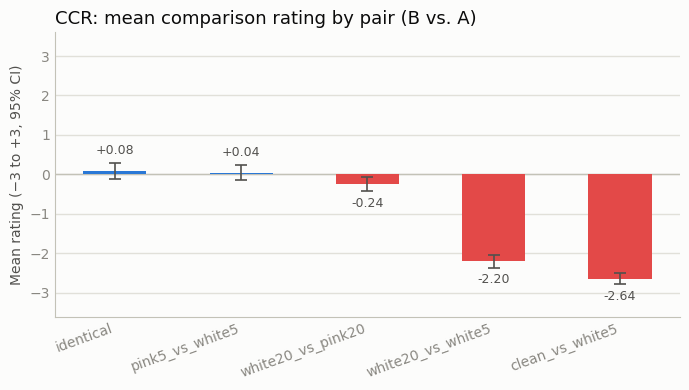

In [5]:
ccr_stats = mean_ci(ccr)
ccr_stats = ccr_stats.reindex(ccr_stats["mean"].sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ccr_stats))
colors = [DIVERGING_POS if m >= 0 else DIVERGING_NEG for m in ccr_stats["mean"]]
bars = ax.bar(x, ccr_stats["mean"], width=0.5, color=colors, zorder=3,
              yerr=ccr_stats["ci95"], capsize=4,
              error_kw={"ecolor": INK_SECONDARY, "elinewidth": 1.2, "capthick": 1.2})
for xi, row in zip(x, ccr_stats.itertuples()):
    label_y = row.mean + row.ci95 + 0.15 if row.mean >= 0 else row.mean - row.ci95 - 0.15
    va = "bottom" if row.mean >= 0 else "top"
    ax.text(xi, label_y, f"{row.mean:+.2f}", ha="center", va=va, fontsize=9, color=INK_SECONDARY)
ax.axhline(0, color=BASELINE, linewidth=1, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(ccr_stats.index, rotation=20, ha="right")
ax.set_ylabel("Mean rating (−3 to +3, 95% CI)")
ax.set_ylim(-3.6, 3.6)
ax.set_title("CCR: mean comparison rating by pair (B vs. A)", color=INK_PRIMARY, fontsize=13, loc="left")
style_axes(ax)
fig.tight_layout()
plt.show()

## White vs. pink noise, by SNR (ACR)

A real comparison between two series, so this is the one chart that uses two categorical hues (in their documented fixed order) with a legend.

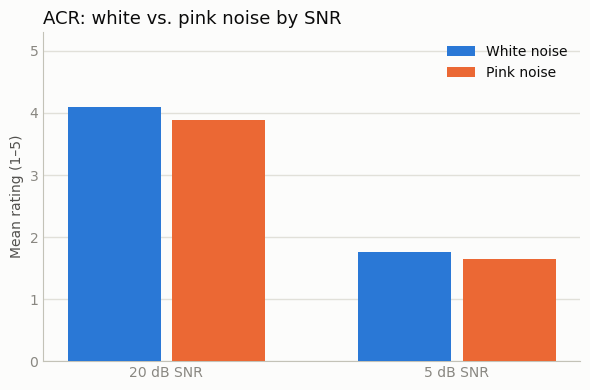

In [6]:
snr_levels = ["20db", "5db"]
snr_labels = ["20 dB SNR", "5 dB SNR"]
white_means = [acr_stats.loc[f"white_{s}", "mean"] for s in snr_levels]
pink_means = [acr_stats.loc[f"pink_{s}", "mean"] for s in snr_levels]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(snr_labels))
bar_w = 0.32
ax.bar(x - bar_w / 2 - 0.02, white_means, width=bar_w, color=SERIES_1, zorder=3, label="White noise")
ax.bar(x + bar_w / 2 + 0.02, pink_means, width=bar_w, color=SERIES_2, zorder=3, label="Pink noise")
ax.set_xticks(x)
ax.set_xticklabels(snr_labels)
ax.set_ylabel("Mean rating (1–5)")
ax.set_ylim(0, 5.3)
ax.set_title("ACR: white vs. pink noise by SNR", color=INK_PRIMARY, fontsize=13, loc="left")
ax.legend(frameon=False)
style_axes(ax)
fig.tight_layout()
plt.show()

## Rating spread per condition (ACR)

Box plots show the distribution across all 50 listeners, not just the mean.

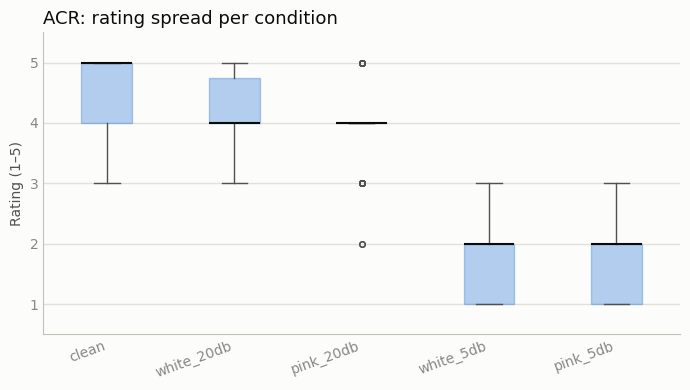

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
order = acr_stats.index.tolist()
data = [acr.loc[acr["itemId"] == item_id, "rating"].values for item_id in order]
bp = ax.boxplot(data, positions=np.arange(len(order)), widths=0.4, patch_artist=True,
                 medianprops={"color": INK_PRIMARY, "linewidth": 1.5},
                 boxprops={"facecolor": SERIES_1, "edgecolor": SERIES_1, "alpha": 0.35},
                 whiskerprops={"color": INK_SECONDARY}, capprops={"color": INK_SECONDARY},
                 flierprops={"markeredgecolor": INK_SECONDARY, "markersize": 4})
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("Rating (1–5)")
ax.set_ylim(0.5, 5.5)
ax.set_title("ACR: rating spread per condition", color=INK_PRIMARY, fontsize=13, loc="left")
style_axes(ax)
fig.tight_layout()
plt.show()

## Listener leniency

Some listeners rate systematically higher or lower than others. Distribution of each listener's mean rating across all ACR items:

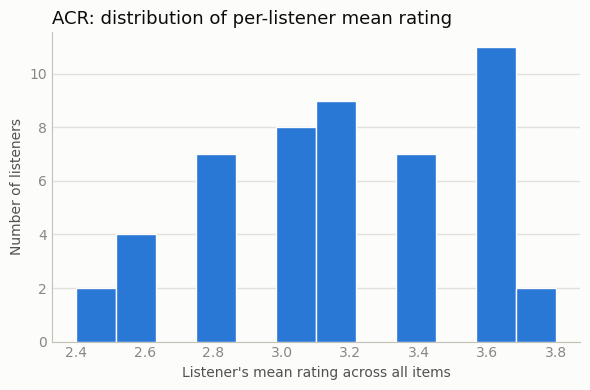

In [8]:
listener_means = acr.groupby("participantId")["rating"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(listener_means, bins=12, color=SERIES_1, zorder=3, edgecolor=SURFACE, linewidth=1)
ax.set_xlabel("Listener's mean rating across all items")
ax.set_ylabel("Number of listeners")
ax.set_title("ACR: distribution of per-listener mean rating", color=INK_PRIMARY, fontsize=13, loc="left")
style_axes(ax)
fig.tight_layout()
plt.show()

## Background data

Background questionnaire answers (e.g. age, language skills) are available as `background_<field>` columns for further analysis, e.g.:

```python
acr.groupby("background_languageSkills")["rating"].mean()
```

In [9]:
acr.groupby("background_languageSkills")["rating"].mean().sort_values(ascending=False)

background_languageSkills
Basic           3.260000
Fluent          3.182609
Intermediate    3.150000
Native          3.066667
Name: rating, dtype: float64